# Computing the metrics

ReconEval scores a `(true, reconstructed)` AnnData pair against the
statistical, biological and perturbational metrics used in the paper.
This page covers the user-facing API one metric at a time, then the
one-call wrapper and the rank-percentile aggregation used for
cross-method comparisons.

The same code applies to any reconstruction output — PCA, AE, VAE,
foundation-model + decoder, perturbation prediction. Swap the loader
cell for your own data and the rest of the notebook is unchanged.

In [1]:
import sys, warnings
from pathlib import Path

# Prefer the public src over any pip-installed sc_reconstruction (which may
# come from a stale private clone in the active env).
sys.path.insert(0, str(Path("..").resolve() / "src"))

import numpy as np
import pandas as pd
from anndata import AnnData

from sc_reconstruction.metrics import (
    load_cell_cycle_genes, load_cytokine_dict_from_csv, load_progeny,
    metric_r2, metric_mse, metric_energy_distance,
    metric_cellcycle, metric_pathway, metric_coexpression, metric_deg, metric_cytokine,
    compute_statistical_metrics, compute_all_metrics, aggregate_rank_percentile,
)

warnings.filterwarnings("ignore")

/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/numba_cuda/numba/cuda/cudadrv/driver.py", line 314, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)


/home/icb/xiaotong.fu/miniconda3/envs/cstm_scvi_env/lib/python3.12/site-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


## Example pair

We use the tutorial-sized LuCA panel that ships with the repo (500 cells
× 643 genes, already normalised + log1p, gene symbols overlap the
cell-cycle / PROGENy / cytokine resources). We build a paired example by
splitting it into control / perturbed halves, perturbing 30 random genes
in the perturbed half, and producing a "reconstructed" copy by adding
small Gaussian noise to the truth.

In [2]:
import scanpy as sc

FROZEN   = Path("../analysis/data/frozen")
CC_FILE  = FROZEN / "regev_lab_cell_cycle_genes.txt"
CYTO_CSV = FROZEN / "cytokine_act_merged.csv"

# LuCA demo: 500 cells × 643 genes (log-normalised, gene-symbol indexed).
luca = sc.read_h5ad(FROZEN / "luca_demo.h5ad")
genes = luca.var_names.tolist()
var   = pd.DataFrame(index=genes)

# Split LuCA in half: control vs perturbed.
rng = np.random.default_rng(0)
perm = rng.permutation(luca.n_obs)
half = luca.n_obs // 2
X_ctrl_base = luca.X[perm[:half]].astype(float)
X_pert_base = luca.X[perm[half:]].astype(float)

# Truth: control + a 30-gene additive shift in the perturbed half.
de_idx = rng.choice(len(genes), size=30, replace=False)
X_ctrl = X_ctrl_base.copy()
X_pert = X_pert_base.copy()
X_pert[:, de_idx] += 1.5  # shift on log scale (~4-5x fold change)

# Reconstruction: truth + small Gaussian noise.
Xh_ctrl = X_ctrl + rng.normal(0, 0.2, size=X_ctrl.shape)
Xh_pert = X_pert + rng.normal(0, 0.2, size=X_pert.shape)

adata      = AnnData(X_pert.astype(np.float32),  var=var)
recon      = AnnData(Xh_pert.astype(np.float32), var=var)
ctrl       = AnnData(X_ctrl.astype(np.float32),  var=var)
ctrl_recon = AnnData(Xh_ctrl.astype(np.float32), var=var)

# Metric resources.
s_genes, g2m_genes = load_cell_cycle_genes(CC_FILE)
progeny   = load_progeny(organism="human")
cytokines = load_cytokine_dict_from_csv(CYTO_CSV, celltype="B_cell", fdr_threshold=0.05)

print(adata)
print(f"\n{len(s_genes)} S genes, {len(g2m_genes)} G2M genes")
print(f"{progeny['source'].nunique()} PROGENy pathways, {len(cytokines)} cytokines")

AnnData object with n_obs × n_vars = 250 × 643

43 S genes, 54 G2M genes
14 PROGENy pathways, 43 cytokines


## Statistical metrics

Each `metric_*` takes `(truth, reconstruction)` and returns a scalar. R² is higher-is-better,
the others are lower-is-better.

In [3]:
print(f"R^2              = {metric_r2(adata, recon):.4f}")
print(f"MSE              = {metric_mse(adata, recon):.4f}")
print(f"Energy distance  = {metric_energy_distance(adata, recon):.4f}")

compute_statistical_metrics(adata, recon)

R^2              = 0.9988
MSE              = 0.0401
Energy distance  = 0.1725


{'r2': 0.9988042712211609,
 'mse': 0.040113721042871475,
 'energy_distance': 0.1724863052368164}

## Biological metrics

Each biological metric scores the truth and the reconstruction with the same procedure and
correlates them. Resources (gene lists, pathway weights, cytokine signatures) are passed
explicitly so the call is reproducible offline.

In [4]:
# Cell-cycle phase agreement.
cc = metric_cellcycle(adata, recon,
                      s_genes=s_genes, g2m_genes=g2m_genes,
                      min_cells=10)
print("proportion_same_phase =", round(cc["proportion_same_phase"], 4))
print("proportion_mean_diff  =", round(cc["proportion_mean_diff"], 4))

proportion_same_phase = 0.648
proportion_mean_diff  = 0.128


In [5]:
# PROGENy pathway scores per cell, correlated across cells per pathway.
pathway_corr = metric_pathway(adata, recon,
                              progeny_model=progeny,
                              correlation_measure="spearman",
                              min_cells=10, overlap_threshold=3)
print(f"pathway corr (mean over pathways) = {pathway_corr:.4f}")

pathway corr (mean over pathways) = 0.8614


In [6]:
# MSigDB Hallmark gene-set co-expression. Omit `geneset_dict` to fetch from omnipath.
coexpr = metric_coexpression(adata, recon,
                             correlation_measure="spearman",
                             min_cells=10, overlap_threshold=3)
print(f"coexpression similarity = {coexpr:.4f}")

2026-06-11 00:50:33 | [INFO] Downloading data from `https://omnipathdb.org/queries/enzsub?format=json`


2026-06-11 00:50:33 | [INFO] Downloading data from `https://omnipathdb.org/queries/interactions?format=json`


2026-06-11 00:50:33 | [INFO] Downloading data from `https://omnipathdb.org/queries/complexes?format=json`


2026-06-11 00:50:33 | [INFO] Downloading data from `https://omnipathdb.org/queries/annotations?format=json`


2026-06-11 00:50:34 | [INFO] Downloading data from `https://omnipathdb.org/queries/intercell?format=json`


2026-06-11 00:50:34 | [INFO] Downloading data from `https://omnipathdb.org/about?format=text`


2026-06-11 00:50:34 | [INFO] Downloading annotations for all proteins from the following resources: `['MSigDB']`


coexpression similarity = 0.9537


In [7]:
# DEG recovery: compare true (pert-vs-ctrl) DEGs against reconstructed (pert-vs-ctrl) DEGs.
deg = metric_deg(adata, recon,
                 ref_true=ctrl, ref_pred=ctrl_recon,
                 method="wilcoxon", dice_k=[50, 100], min_cells=10)
for k, v in deg.items():
    print(f"  {k:36s} = {v}")

... storing 'group' as categorical


... storing 'group' as categorical


... storing 'group' as categorical


  true_deg_dice_50                     = 0.9375
  true_deg_dice_100                    = 0.9375
  true_deg_pearson                     = nan
  true_deg_spearman                    = nan
  true_deg_pearson_orig_50             = 0.9999334812164307
  true_deg_spearman_orig_50            = 0.9982202447163514
  true_deg_pearson_orig_100            = 0.9999334812164307
  true_deg_spearman_orig_100           = 0.9982202447163514
  true_mean_genediff_pearson           = 0.999174952507019
  true_mean_genediff_spearman          = 0.808895023954095
  pred_deg_dice_50                     = 0.9523809523809523
  pred_deg_dice_100                    = 0.9523809523809523
  pred_deg_pearson                     = nan
  pred_deg_spearman                    = nan
  pred_deg_pearson_orig_50             = nan
  pred_deg_spearman_orig_50            = nan
  pred_deg_pearson_orig_100            = nan
  pred_deg_spearman_orig_100           = nan
  pred_mean_genediff_pearson           = 0.9983597993850708
  pred

In [8]:
# Cytokine activity: score each Immune-Dictionary signature on both sides, correlate.
cyto = metric_cytokine(adata, recon,
                       cytokine_dict=cytokines,
                       correlation="spearman",
                       min_genes=5)
print(f"cytokine corr (Spearman) = {cyto:.4f}")

cytokine corr (Spearman) = 0.9341


## All metrics in one call

`compute_all_metrics` runs every metric whose required inputs are available
and returns one flat `{metric_name: score}` dict. Metrics with missing
inputs come back as `NaN`.

In [9]:
scores = compute_all_metrics(
    adata, recon,
    s_genes=s_genes, g2m_genes=g2m_genes,
    progeny_model=progeny,
    cytokine_dict=cytokines,
    deg_refs=(ctrl, ctrl_recon),
)
pd.Series(scores, name="score").to_frame()

2026-06-11 00:50:44 | [INFO] Downloading annotations for all proteins from the following resources: `['MSigDB']`


... storing 'group' as categorical


... storing 'group' as categorical


... storing 'group' as categorical


,score
r2,0.998804
mse,0.040114
energy_distance,0.172486
cellcycle_proportion_same_phase,0.656000
coexpression,0.955467
pathway,0.897377
deg_dice_at_100,0.952381
deg_logfc_spearman,0.728395
cytokine,0.934066


## Rank-percentile across methods

To rank several methods against each other, stack per-metric scores into a DataFrame
(rows = methods, columns = metrics) and call `aggregate_rank_percentile`. The paper formula is

$$\mathrm{rp}_i(m) = \frac{|M| - \mathrm{rank}_i(m)}{|M| - 1}$$

with rank 1 = best. Direction (higher- vs lower-is-better) comes from `HIGHER_IS_BETTER`.

Below we fit PCA at three latent sizes (10, 32, 128) on the truth and use its inverse-transform
as the reconstruction. The expected outcome is a clean monotonic ranking: PCA-128 should win
on most metrics, PCA-10 should be worst.

In [10]:
from sklearn.decomposition import PCA

dims = [10, 32, 128]
scored = {}

for d in dims:
    pca = PCA(n_components=d, random_state=0).fit(np.vstack([adata.X, ctrl.X]))
    recon_d      = AnnData(pca.inverse_transform(pca.transform(adata.X)).astype(np.float32), var=var)
    ctrl_recon_d = AnnData(pca.inverse_transform(pca.transform(ctrl.X )).astype(np.float32), var=var)
    scored[f"PCA-{d}"] = compute_all_metrics(
        adata, recon_d,
        s_genes=s_genes, g2m_genes=g2m_genes,
        progeny_model=progeny,
        cytokine_dict=cytokines,
        deg_refs=(ctrl, ctrl_recon_d),
    )

raw = pd.DataFrame(scored).T
print("raw scores:")
print(raw.to_string(float_format=lambda x: f"{x:.4f}"))

rp = aggregate_rank_percentile(raw)
print("\nrank-percentiles (1.0 = best):")
print(rp.round(3))

print("\noverall (mean rp across metrics):")
print(rp.mean(axis=1).sort_values(ascending=False).round(3))

2026-06-11 00:50:54 | [INFO] Downloading annotations for all proteins from the following resources: `['MSigDB']`


... storing 'group' as categorical


... storing 'group' as categorical


... storing 'group' as categorical


2026-06-11 00:51:04 | [INFO] Downloading annotations for all proteins from the following resources: `['MSigDB']`


...

2026-06-11 00:51:14 | [INFO] Downloading annotations for all proteins from the following resources: `['MSigDB']`


... storing 'group' as categorical


... storing 'group' as categorical


... storing 'group' as categorical


raw scores:
            r2    mse  energy_distance  cellcycle_proportion_same_phase  coexpression  pathway  deg_dice_at_100  deg_logfc_spearman  cytokine
PCA-10  1.0000 0.0574           0.7947                           0.7880        0.8835   0.6493           0.4615              0.9967    0.9835
PCA-32  1.0000 0.0416           0.3173                           0.7920        0.9351   0.7825           0.4615              0.9970    0.9835
PCA-128 1.0000 0.0136           0.0429                           0.8320        0.9649   0.9452           0.6667              0.9994    1.0000

rank-percentiles (1.0 = best):
          r2  mse  energy_distance  cellcycle_proportion_same_phase  \
PCA-10   0.0  0.0              0.0                              0.0   
PCA-32   0.5  0.5              0.5                              0.5   
PCA-128  1.0  1.0              1.0                              1.0   

         coexpression  pathway  deg_dice_at_100  deg_logfc_spearman  cytokine  
PCA-10            0.0  

## Funky heatmap

`funky_heatmap` packages the Fig 2 summary view as a one-call plot. Pass the
raw `compute_all_metrics` matrix (rows = methods, columns = metrics): each
cell is coloured by the per-column rank-percentile (1.0 = best), a white
circle's area scales with that rank-percentile, the raw score is annotated
in the cell, and the right-hand columns aggregate per family
("statistical", "biological", "perturbational") plus an "overall" mean.

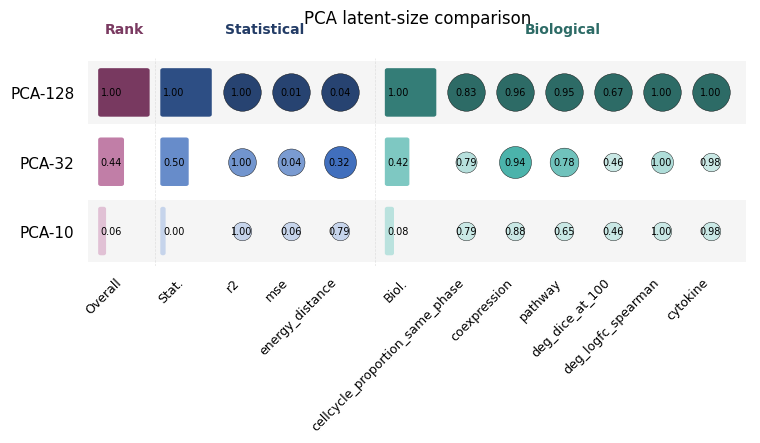

In [11]:
from sc_reconstruction.metrics import funky_heatmap
import matplotlib.pyplot as plt

ax = funky_heatmap(raw, title="PCA latent-size comparison")
plt.show()

For batch evaluation at paper scale (zarr stores, multiprocessing), see
`sc_reconstruction.metrics.base_eval` (`MetricsBatchEvaluator`) — not
part of the public API but reachable when needed.